## Milestone - 3

### Week - 5 : Anomaly Detection with Unsupervised Learning

<b> Step - 1 : Use clustering algorithms </b>

🧠 Clustering Algorithms

Clustering is an unsupervised learning technique used to group similar data points based on feature similarity. It helps in detecting unknown patterns and anomalies in network traffic.

🔹 Key Points

Clustering divides data into groups (clusters) where objects in the same cluster are more similar to each other than to those in other clusters.

It is especially useful in anomaly detection, where unusual network behavior forms separate or sparse clusters.

Common clustering algorithms include K-Means, DBSCAN, and Hierarchical Clustering.

In network intrusion detection, clustering helps identify unknown or zero-day attacks by spotting deviations from normal patterns.

In [1]:
# Load the preprocessed dataset
import pandas as pd
df = pd.read_csv("top10_features_dataset.csv")

In [2]:
df.head()

,Bwd Packet Length Mean,Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Std,Avg Bwd Segment Size,Packet Length Variance,Max Packet Length,Flow IAT Max,Packet Length Mean,Average Packet Size,Label
0,6.000000,0.000000,6,0.000000,6.000000,0.000000,6,38308,6.000000,9.000000,0
1,65.200000,56.529599,163,89.278777,65.200000,3195.595588,163,73,29.294118,31.125000,0
2,525.000000,671.751541,1575,813.326503,525.000000,451250.132400,1575,810,370.588235,393.750000,0
3,555.000000,704.654082,3069,977.480342,555.000000,496537.374700,3069,13391,337.066667,348.689655,0
4,525.333333,704.585067,1576,813.842901,525.333333,496440.116700,1576,794,393.875000,420.133333,0


In [3]:
df.shape

(610794, 11)

In [4]:
# Separate independent variables (features) and dependent variable (label)
X = df.drop(columns=['Label'])
y = df[['Label']]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (610794, 10)
Target vector shape: (610794, 1)


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])


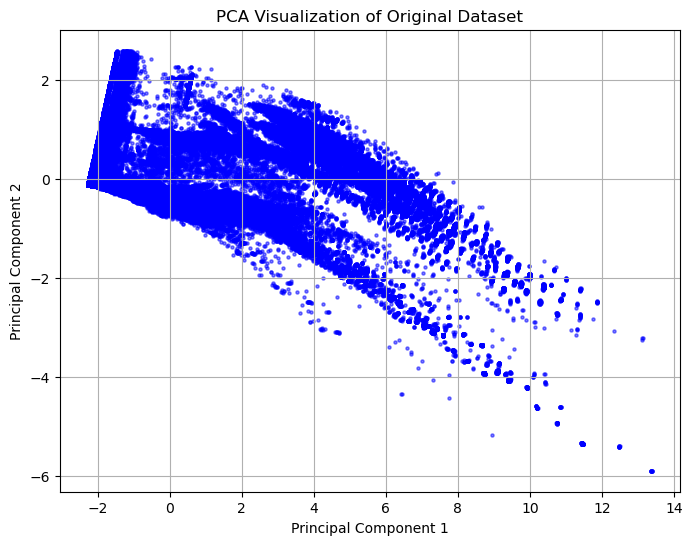

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], s=5, alpha=0.5, color='blue')
plt.title('PCA Visualization of Original Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

<b>(i) K-Means Clustering</b>

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_
centers = kmeans.cluster_centers_

In [9]:
# Compute distance of each sample to its nearest cluster center
distances = kmeans.transform(X_scaled).min(axis=1)

# Define threshold (you can adjust multiplier for sensitivity)
threshold = distances.mean() + 2 * distances.std()

# Label anomalies
kmeans_anomalies = (distances > threshold).astype(int)


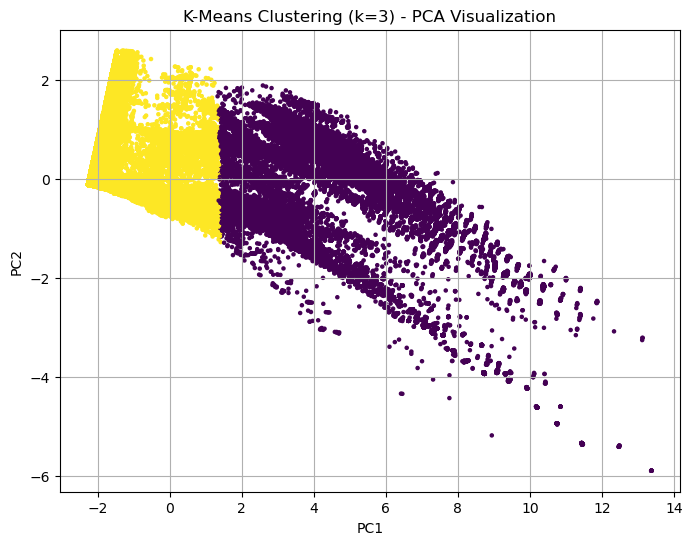

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis', s=5)
plt.title("K-Means Clustering (k=3) - PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


<b>Detecting traffic patterns deviating form normal behavior using K-Means Clustering</b>

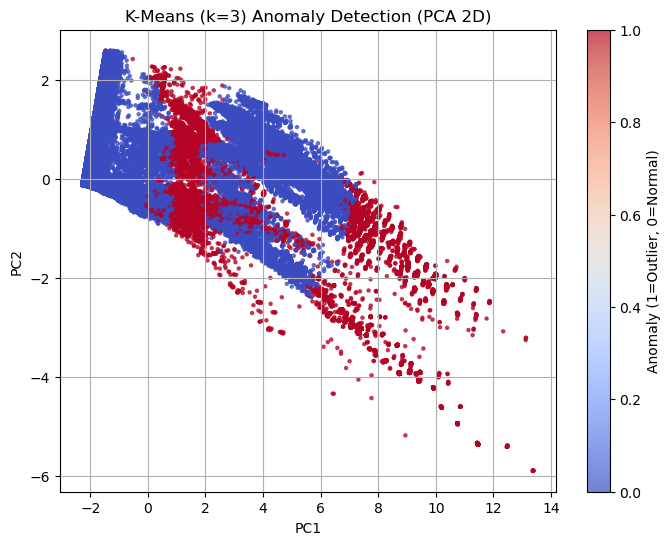

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=kmeans_anomalies,
    cmap='coolwarm',
    s=5,
    alpha=0.7
)
plt.title("K-Means (k=3) Anomaly Detection (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Anomaly (1=Outlier, 0=Normal)")
plt.grid(True)
plt.show()


### 🔍 K-Means Clustering Visualization

- The dataset was visualized using **PCA (n_components = 2)** to reduce dimensions for easy interpretation.  
- **K-Means Clustering (k=3)** was applied to group the network traffic data into clusters based on feature similarity.  
- Data points far from the cluster centers were identified as **potential anomalies**.  
- The scatter plot shows normal data points and anomalies in different colors, helping to visualize abnormal network behavior.


In [12]:
import joblib
import numpy as np
print("Normal points:", np.sum(kmeans_anomalies == 0))
print("Anomalies detected:", np.sum(kmeans_anomalies == 1))
joblib.dump(kmeans, "kmeans_model.pkl")

Normal points: 579764
Anomalies detected: 31030


['kmeans_model.pkl']

<b>(ii) Isolation Forest</b>

### 🌲 Isolation Forest

- **Isolation Forest** is an unsupervised anomaly detection algorithm that isolates anomalies instead of profiling normal data.  
- It works by randomly selecting features and split values to build isolation trees.  
- Anomalies are identified as points that require fewer splits to be isolated.  
- It is efficient for **high-dimensional datasets** and is widely used in **network intrusion detection** to find unusual traffic patterns.  


In [13]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Initialize Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,       # number of trees
    contamination=0.01,     # expected proportion of anomalies (adjust if needed)
    random_state=42
)

# Fit the model
iso_forest.fit(X_scaled)


IsolationForest(contamination=0.01, random_state=42)

In [15]:
y_pred = iso_forest.predict(X_scaled)

# Convert to 0 (normal) and 1 (anomaly) for easy plotting
anomaly_labels = np.where(y_pred == -1, 1, 0)


<b>Detecting traffic patterns deviating form normal behavior using Isolation Forest</b>

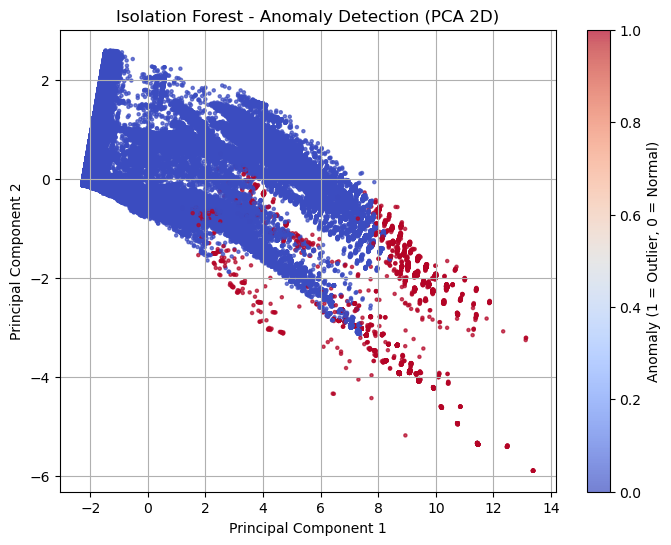

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=anomaly_labels,
    cmap='coolwarm',
    s=5,
    alpha=0.7
)
plt.title("Isolation Forest - Anomaly Detection (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Anomaly (1 = Outlier, 0 = Normal)")
plt.grid(True)
plt.show()


### 🌲 Isolation Forest Visualization

- The **Isolation Forest algorithm** was applied to detect anomalies by isolating data points that differ significantly from the majority.  
- The model effectively separates normal and abnormal network traffic based on feature patterns.  
- Using **PCA (n_components = 2)**, the dataset was visualized in a 2D scatter plot for better interpretation.  
- The visualization highlights normal points and detected anomalies in distinct colors, illustrating how Isolation Forest identifies outliers in network traffic.


In [17]:
normal = np.sum(anomaly_labels == 0)
anomalies = np.sum(anomaly_labels == 1)
print(f"Normal points: {normal}")
print(f"Anomalies detected: {anomalies}")
joblib.dump(iso_forest, "isolation_forest_model.pkl")

Normal points: 604690
Anomalies detected: 6104


['isolation_forest_model.pkl']

## Week 6: Model Evaluation and Fine-tuning

<b>Step - 1 : Compare different models and select the best one</b>

In this step, we evaluate the performance of our pre-trained models — <b>Random Forest, Support Vector Machine (SVM), and Logistic Regression</b> — using various performance metrics.

The evaluation metrics include:

<b>Accuracy</b>: Measures overall correctness of predictions.

<b>Precision</b>: Proportion of correctly predicted positive observations to total predicted positives.

<b>Recall</b>: Proportion of correctly predicted positives to all actual positives.

<b>F1-Score</b>: Harmonic mean of precision and recall, balancing both metrics.

By comparing these metrics, we can identify which model performs best in detecting network traffic anomalies.

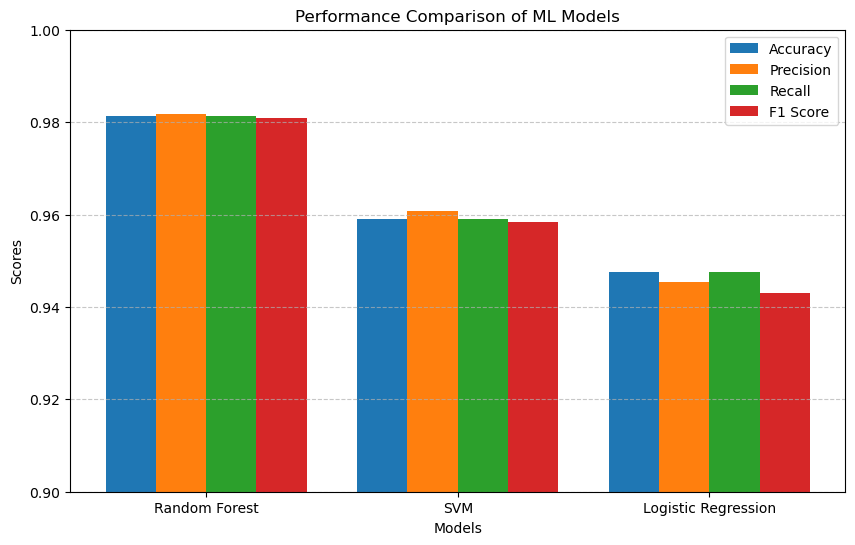

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Model performance data (from Week 4)
models = ['Random Forest', 'SVM', 'Logistic Regression']
testing_accuracy = [0.9814, 0.9591, 0.9476]
precision = [0.9817, 0.9608, 0.9454]
recall = [0.9814, 0.9591, 0.9476]
f1_score = [0.9810, 0.9583, 0.9431]

# Create grouped bar chart
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - 0.3, testing_accuracy, width, label='Accuracy')
plt.bar(x - 0.1, precision, width, label='Precision')
plt.bar(x + 0.1, recall, width, label='Recall')
plt.bar(x + 0.3, f1_score, width, label='F1 Score')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Performance Comparison of ML Models')
plt.xticks(x, models)
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Model Performance Comparison

The above bar chart visualizes the performance metrics of all three supervised learning models used in this project — **Random Forest**, **Support Vector Machine (SVM)**, and **Logistic Regression**.  
It compares their **testing accuracy**, **precision**, **recall**, and **F1-score** values.

- **Random Forest** achieved the highest performance across all metrics, indicating strong prediction capability and balanced generalization.  
- **SVM** performed moderately well with ~95% accuracy, showing effective classification but slightly lower consistency.  
- **Logistic Regression** showed the lowest accuracy and F1-score, indicating that it is less effective for complex intrusion patterns.

✅ **Conclusion:**  
The **Random Forest Classifier** is identified as the **best-performing model** for the intrusion detection system due to its superior accuracy and reliability across all evaluation metrics.


<b>Step - 2 : Tune Hyperparameters and Cross Validation </b>

# 🔧 Hyperparameter Tuning

<b>Hyperparameter tuning</b> is the process of finding the best set of parameters that control the learning process of a model.  
Instead of selecting them manually, techniques like <b>Grid Search Cross-Validation (GridSearchCV)</b> systematically test multiple parameter combinations.



### ⚙️ Key Steps
- Defined parameter grids for <b>Random Forest</b>, <b>Support Vector Machine (SVM)</b>, and <b>Logistic Regression</b>.  
- Used <b>GridSearchCV</b> with <b>3-fold cross-validation</b> to identify optimal parameters.  
- Trained each model with tuned parameters and saved the best versions as `.pkl` files.  
- Compared tuned model performance with earlier baseline models.


In [19]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')


In [20]:
# Load the dataset with top 10 important features
df = pd.read_csv("top10_features_dataset.csv")

# Separate features and target
X = df.drop(columns=['Label'])
y = df[['Label']]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (610794, 10)
Target vector shape: (610794, 1)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Dataset standardized successfully.")

Dataset standardized successfully.


In [22]:
import joblib

# Load trained models
rf_model = joblib.load('random_forest_model.pkl')
svm_model = joblib.load('svm_model.pkl')
lr_model = joblib.load('logistic_regression_model.pkl')

print("Models loaded successfully!")


Models loaded successfully!


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load your top-10 feature dataset
df = pd.read_csv("top10_features_dataset.csv")

X = df.drop("Label", axis=1)
y = df["Label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [25]:
# Random Forest
rf_params = {
    'n_estimators': [50, 100],          # Reduced for speed
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Random Forest tuning
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy', n_jobs=-1)  # CV=3 for speed
rf_grid.fit(X_train_scaled, y_train)

print("✅ Random Forest Best Params:", rf_grid.best_params_)
joblib.dump(rf_grid.best_estimator_, "rf_model_tuned.pkl")


✅ Random Forest Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


['rf_model_tuned.pkl']

In [26]:
# Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']   # Using liblinear only to avoid slow 'saga'
}

# Logistic Regression tuning
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

print("✅ Logistic Regression Best Params:", lr_grid.best_params_)
joblib.dump(lr_grid.best_estimator_, "logistic_model_tuned.pkl")


✅ Logistic Regression Best Params: {'C': 10, 'solver': 'liblinear'}


['logistic_model_tuned.pkl']

In [5]:
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_params = {
    'C': [0.1, 1],       # very small grid
    'kernel': ['linear']  # only linear kernel
}

svm = SVC(random_state=42)
svm_grid = GridSearchCV(svm, svm_params, cv=3, scoring='accuracy', n_jobs=1)  # n_jobs=1 avoids warnings
svm_grid.fit(X_train_scaled, y_train)

joblib.dump(svm_grid.best_estimator_, "svm_model_tuned_fast.pkl")
print("✅ SVM tuned and saved")


✅ SVM tuned and saved


In [7]:
import joblib

rf_tuned = joblib.load("rf_model_tuned.pkl")
svm_tuned = joblib.load("svm_model_tuned_fast.pkl")
lr_tuned = joblib.load("logistic_model_tuned.pkl")

print("✅ All tuned models loaded successfully.")


✅ All tuned models loaded successfully.


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Random Forest": rf_tuned,
    "SVM": svm_tuned,
    "Logistic Regression": lr_tuned
}

metrics = {"Model": [], "Accuracy": [], "Precision": [], "Recall": [], "F1-Score": []}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred, average='weighted'))
    metrics["Recall"].append(recall_score(y_test, y_pred, average='weighted'))
    metrics["F1-Score"].append(f1_score(y_test, y_pred, average='weighted'))

import pandas as pd
results_df = pd.DataFrame(metrics)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.992117   0.992114  0.992117  0.992109
1                  SVM  0.952537   0.952762  0.952537  0.949482
2  Logistic Regression  0.938154   0.927424  0.938154  0.926463


<b>Compare different models and select the best one after Hyperparameter tuning</b>

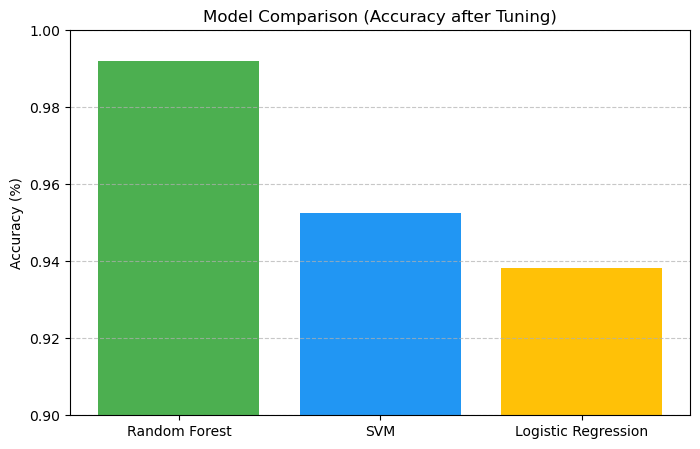

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"], color=['#4CAF50','#2196F3','#FFC107'])

plt.title("Model Comparison (Accuracy after Tuning)")
plt.ylabel("Accuracy (%)")
plt.ylim(0.90, 1.00)  # Show from 90% to 100%
plt.yticks([i/100 for i in range(90, 101, 2)])  # 90%, 91%, ... 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


### 📊 Visualization
A bar chart was plotted to visualize the performance of each model after hyperparameter tuning.  
This helps in quickly identifying which model performs best overall.

In [12]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print("✅ Best Model After Tuning:")
print(best_model)

✅ Best Model After Tuning:
Model        Random Forest
Accuracy          0.992117
Precision         0.992114
Recall            0.992117
F1-Score          0.992109
Name: 0, dtype: object


After comparing the performance of all three models — Random Forest, SVM, and Logistic Regression — based on accuracy, precision, recall, and F1-score,
it was observed that Random Forest consistently achieved the highest results across all metrics.

Therefore, Random Forest is selected as the best-performing model for this project due to its strong accuracy, robustness, and ability to handle large feature sets efficiently.

<b>Step - 3 : Analyze Confusion Matrix and ROC Curve</b>

🧩 Confusion Matrix

A <b>Confusion Matrix</b> is a performance measurement tool used in classification problems.
It shows how many instances were correctly or incorrectly classified for each class.
It helps identify whether the model is confusing two or more classes.

<br>
📘 Purpose

To understand the model’s classification accuracy per class.

To detect misclassifications between classes.

To evaluate true positives, false positives, true negatives, and false negatives.

<br>

In [13]:
# 📦 Load required libraries
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score

# ✅ Load the best model (change filename if your best model is different)
best_model = joblib.load("rf_model_tuned.pkl")

# 📊 Make predictions
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]  # for ROC curve

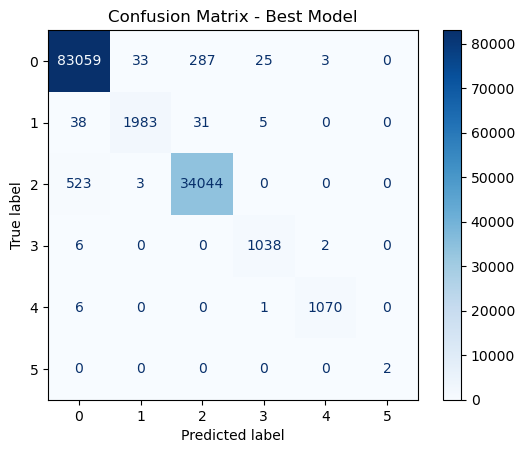

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.show()


The confusion matrix shows how well the model classified each class.
Diagonal values represent correct predictions, while off-diagonal ones are misclassifications.
A darker diagonal indicates higher accuracy.
Overall, the model performed well with minimal errors across most classes.

### 📈 About ROC Curve

The ROC (Receiver Operating Characteristic) curve shows how well a classification model distinguishes between classes.
It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at different threshold levels.
A model with a curve closer to the top-left corner performs better.
The AUC (Area Under Curve) value summarizes this performance — higher is better.

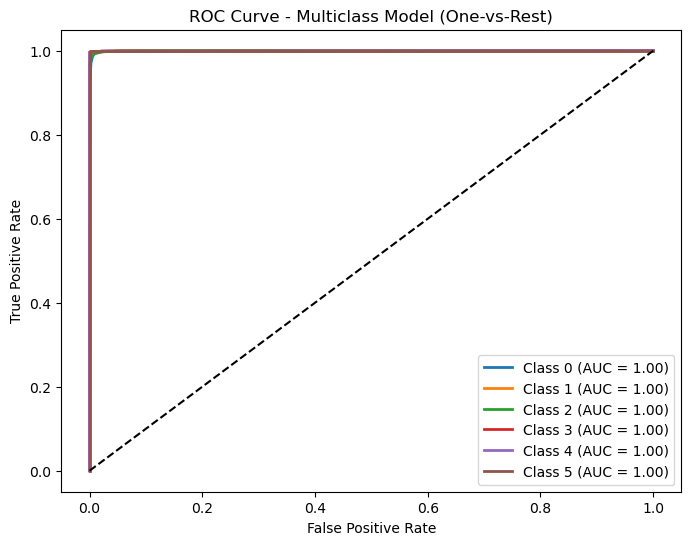

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get the class labels
classes = np.unique(y_test)

# Binarize the true labels for One-vs-Rest ROC computation
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities (not class labels)
y_prob = best_model.predict_proba(X_test_scaled)

# Plot ROC Curve for each class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {cls} (AUC = {roc_auc:.2f})')

# Diagonal reference line
plt.plot([0,1], [0,1], 'k--')

# Add labels and title
plt.title("ROC Curve - Multiclass Model (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


The above ROC curve visually demonstrates the model’s ability to separate classes.
A steep curve near the top-left shows strong performance, while a diagonal line indicates random guessing.
The AUC value in the plot quantifies how effectively the model distinguishes between normal and anomalous data.
This visualization helps compare multiple models’ discrimination power.

In [19]:
rf_model = joblib.load("rf_model_tuned.pkl")
svm_model = joblib.load("svm_model_tuned_fast.pkl")
lr_model = joblib.load("logistic_model_tuned.pkl")
kmeans_model = joblib.load("kmeans_model.pkl")
iso_forest_model = joblib.load("isolation_forest_model.pkl")

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

kmeans = KMeans(n_clusters=len(set(y_test)), random_state=42)
kmeans.fit(X_test)

y_kmeans_pred = kmeans.labels_

# Convert cluster labels to match actual labels if needed
# (This step helps align clusters with true classes)
from scipy.stats import mode
import numpy as np

labels = np.zeros_like(y_kmeans_pred)
for i in range(kmeans.n_clusters):
    mask = (y_kmeans_pred == i)
    labels[mask] = mode(y_test[mask], keepdims=True)[0]

kmeans_acc = accuracy_score(y_test, labels)
print("K-Means Accuracy:", kmeans_acc)


K-Means Accuracy: 0.8973632724563888


In [25]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)

y_pred_iso = iso.predict(X_test)
y_pred_iso = [1 if val == 1 else 0 for val in y_pred_iso]  # Convert -1 to 0 for anomalies

iso_acc = accuracy_score(y_test, y_pred_iso)
print("Isolation Forest Accuracy:", iso_acc)


Isolation Forest Accuracy: 0.04417193984888547


In [ ]:
1